# **World Retail Data**

# **import library**

In [160]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from sklearn.impute import KNNImputer

In [161]:
file = "/content/drive/MyDrive/Praktikum_AVD/business_understanding_AVD/online_retail_real_world.csv"
df = pd.read_csv(file)
df

,OrderID,CustomerID,ProductName,Brand,Raw_Weight,Country,OrderDate,UnitPrice
0,REC-861088,6120,Perly,Perly,100 g,"Morocco,United States",2024-02-22,13.18
1,REC-900952,12550,Prince Goût Chocolat,LU,300 g,"Algeria,Belgium,France,French Polynesia,German...",2024-11-13,1.50
2,REC-595965,6705,Excellence Noir Prodigieux 90% Cacao,"Lindt EXCELLENCE,Lindt",100g,"Argelia,Austria,Bélgica,Bulgaria,Canadá,Repúbl...",2025-02-02,12.99
3,REC-942653,8645,Tonik,عربي,22 g,Maroc,2024-12-11,14.82
4,REC-885998,14430,Sésame,Gerblé,230g,"Belgium, Bulgaria, France, en:switzerland",2025-08-21,18.40
...,...,...,...,...,...,...,...,...
2995,REC-867989,13739,Cocoa Orange,Nakd,NaN,en:GB,2025-03-30,3.78
2996,REC-774268,8212,Chocolate For Change Dark Chocolate With Orange,Coop,100 g,"Germany,en:united-kingdom",2025-03-23,14.41
2997,REC-432494,13398,Lait dessert,Fin Carré,200 g,"France, en:united-kingdom",2025-01-03,17.58
2998,REC-117507,8050,Rusticotti,Balocco,700,"Francia,Italia",2025-09-02,21.35


# **Business Understanding**


## **Business Objective**

**Isi Dataset:**
Dataset ini merupakan catatan transaksi retail online yang mencakup berbagai produk (seperti cokelat, biskuit, dan makanan ringan) dari berbagai merek global. Data ini mencatat detail pesanan, ID pelanggan, berat produk, asal negara, hingga harga per unit.

**Masalah yang ada:**
Meskipun terdapat data transaksi dalam dataset ini, perusahaan mungkin akan mengalami kesulitan menentukan strategi harga dan manajemen stok yang efisien. Tanpa analisis yang mendalam, sulit untuk mengetahui produk mana yang paling laris atau jarang dibeli, bagaimana distribusi berat produk memengaruhi harga, atau di negara mana produk tersebut paling banyak tersedia.

**Tujuan analisis:**
adapun tujuan analisis ini dilakukan adalah untuk membantu perusahaan mengetahui produk mana yang laris di pasaran apa saja yang sering dibeli atau produk mana yang jarang dipesan kemudian membantu perusahaan mengetahui target pasar mereka nantinya

## **assess situation**

**Kondisi Dataset:**

-Format Berat yang Tidak Konsisten: Kolom Raw_Weight berisi teks seperti "150 g", "75 g", "170g", hingga "3".


-Data Geografis yang Kompleks: Kolom Country berisi daftar banyak negara dalam satu baris (misal: "France, Italy, Spain"). Ini menyulitkan jika kita ingin melakukan filter per negara secara spesifik.

-Skala harga yang tidak Teratur:Urutannya acak jadi harga tidak ter-urut berdasarkan yang paling mahal atau paling murah

-data tidak terdefinisi: dalam beberapa kolom atau baris terdapat teks NaN

## **analytic goals**

**Untuk mengatasi beberapa masalah di atas, berikut ini adalah target analisis yang akan dilakukan:**

-konversi ke jenis satuan yang sama: Mengonversi Raw_Weight menjadi angka numerik murni contohnya "gram" agar bisa dianalisis hubungannya dengan harga.

-Market Reach Mapping: Memecah data negara untuk melihat sebaran jangkauan produk secara global.

## **Project Plan**

**Berikut adalah langkah-langkah kerja yang akan diambil:**

Data Discovery (Memahami Data):


-Memeriksa tipe data setiap kolom dan menghitung data yang hilang atau NaN.


**Data Cleaning (Pembersihan):**

-Mengubah jenis satuan "g", "kg", atau "100g" dari kolom berat dan mengubahnya ke tipe yang sama.


-Mengisi atau mengategorikan merek yang hilang sebagai "Unknown".


-Memastikan tanggal order terbaca sebagai format tanggal yang benar.


-Exploratory Data Analysis (EDA): Membuat visualisasi distribusi harga, berat produk, dan frekuensi pesanan per bulan, agar rapi dan urut


-Reporting & Insights: Menyusun kesimpulan mengenai produk mana yang paling potensial untuk dipromosikan lebih lanjut.

# **Deskripsi Data**

## **Informasi Dasar**

In [162]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   OrderID      3000 non-null   object 
 1   CustomerID   3000 non-null   int64  
 2   ProductName  2904 non-null   object 
 3   Brand        2665 non-null   object 
 4   Raw_Weight   2488 non-null   object 
 5   Country      3000 non-null   object 
 6   OrderDate    3000 non-null   object 
 7   UnitPrice    2615 non-null   float64
dtypes: float64(1), int64(1), object(6)
memory usage: 187.6+ KB


Berdasarkan data di atas, dapat diketahui bahwa dataset ini memiliki 3000 Baris dan 8 Kolom

## **Informasi Lanjutan**

In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   OrderID      3000 non-null   object 
 1   CustomerID   3000 non-null   int64  
 2   ProductName  2904 non-null   object 
 3   Brand        2665 non-null   object 
 4   Raw_Weight   2488 non-null   object 
 5   Country      3000 non-null   object 
 6   OrderDate    3000 non-null   object 
 7   UnitPrice    2615 non-null   float64
dtypes: float64(1), int64(1), object(6)
memory usage: 187.6+ KB


Informasi lanjutan dalam kolom:

1. OrderID: Jumlah baris: 3000 | Tipe data: object | Deskripsi: ID unik untuk setiap pesanan.

2. CustomerID: Jumlah baris: 3000 | Tipe data: int64 | Deskripsi: ID unik untuk setiap pelanggan.

3. ProductName: Jumlah baris: 2904 | Tipe data: object | Deskripsi: Nama produk yang dibeli.

4. Brand: Jumlah baris: 2665 | Tipe data: object | Deskripsi: Merek atau brand dari produk.

5. Raw_Weight: Jumlah baris: 2488 | Tipe data: object | Deskripsi: Berat mentah/kotor dari produk (dalam format teks).

6. Country: Jumlah baris: 3000 | Tipe data: object | Deskripsi: Negara asal atau tujuan pengiriman.

7. OrderDate: Jumlah baris: 3000 | Tipe data: object | Deskripsi: Tanggal dilakukannya transaksi pesanan.

8. UnitPrice: Jumlah baris: 2615 | Tipe data: float64 | Deskripsi: Harga satuan per produk.

## **Informasi Statistik Deskriptif**

In [164]:
df.describe(include='all')

,OrderID,CustomerID,ProductName,Brand,Raw_Weight,Country,OrderDate,UnitPrice
count,3000,3000.000000,2904,2665,2488,3000,3000,2615.000000
unique,2992,NaN,2726,1110,729,1013,718,NaN
top,REC-189159,NaN,Dark Chocolate,Gerblé,100 g,France,2024-08-31,NaN
freq,2,NaN,5,55,159,662,11,NaN
mean,NaN,9989.842333,NaN,NaN,NaN,NaN,NaN,12.992417
std,NaN,2871.959873,NaN,NaN,NaN,NaN,NaN,6.963856
min,NaN,5011.000000,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,7454.750000,NaN,NaN,NaN,NaN,NaN,6.985000
50%,NaN,10066.000000,NaN,NaN,NaN,NaN,NaN,13.160000
75%,NaN,12527.250000,NaN,NaN,NaN,NaN,NaN,18.960000


**1. Count (Kelengkapan Data)**

Berdasarkan data, total baris transaksi seharusnya adalah **3.000**. Maka dapat disimpulkan:

* **UnitPrice** hilang 385 data (3.000 - 2.615)
* **Raw_Weight** hilang 512 data (3.000 - 2.488)
* **Brand** hilang 335 data (3.000 - 2.665)
* **ProductName** hilang 96 data (3.000 - 2.904)
* **Kesimpulan:** Banyak kolom krusial seperti `UnitPrice` (Harga) dan `Brand` memiliki *missing values* yang cukup signifikan (lebih dari 10%). Kolom `OrderID`, `CustomerID`, `Country`, dan `OrderDate` adalah yang paling lengkap (3.000 data).


**2. Mean vs Median (Distribusi Data)**

Analisis ini fokus pada kolom numerik utama, yaitu **UnitPrice**:

* **Kolom UnitPrice**
* **Mean** = 12,99
* **Median (50%)** = 13,16
* **Analisis:** Nilai rata-rata (12,99) hampir sama dengan median (13,16).
* **Kesimpulan:** Distribusi harga produk dalam dataset ini tergolong **simetris (Normal Distribution)**. Tidak ada tanda-tanda *outlier* harga yang ekstrem yang menarik rata-rata terlalu jauh ke atas maupun ke bawah. Produk dijual dengan rentang harga yang cukup merata.



**3. Min dan Max (Validasi Logika)**

* **UnitPrice**
* **Min** = 1,00
* **Max** = 24,99


* **CustomerID**
* **Min** = 5.011
* **Max** = 14.998


* **Kesimpulan:**
* Rentang harga **1,00 hingga 24,99** menunjukkan bahwa bisnis ini fokus pada produk retail harian atau *Fast Moving Consumer Goods* (FMCG) dengan harga terjangkau, bukan barang mewah.
* ID Pelanggan berada dalam rentang yang konsisten (5.000 - 14.000), tidak ditemukan angka nol atau negatif yang biasanya menandakan *error* pada sistem database.


**4. Standar Deviasi (std) - Variabilitas Data**

* **UnitPrice**
* **Mean** = 12,99
* **Std** = 6,96


**Kesimpulan:**
* Nilai standar deviasi (6,96) mencakup sekitar **53% dari nilai rata-rata**. Ini mengindikasikan bahwa variasi harga antar produk cukup moderat.
* Sebagian besar produk (sekitar 68%) kemungkinan besar dijual dalam rentang harga **6,03 hingga 19,95** (Mean ± 1 Std). Data ini cukup stabil untuk diprediksi karena tidak ada fluktuasi harga yang liar.


## **VERIFIKASI KUALITAS DATA**

### **Data Type Check**

Kita akan mengecek tipe data dari setiap kolom apakah sudah sesuai atau tidak. Agar insight serta visualisasi yang akan kita buat menjadi akurat.

In [165]:
df.dtypes

,0
OrderID,object
CustomerID,int64
ProductName,object
Brand,object
Raw_Weight,object
Country,object
OrderDate,object
UnitPrice,float64


Berikut adalah tipe data yang ada didalam dataset beserta penjelasan singkat untuk masing-masing kolom:

 **Data Type**

* **OrderID**: `object` (Teks)
* **CustomerID**: `int64` (Angka Bulat)
* **ProductName**: `object` (Teks)
* **Brand**: `object` (Teks)
* **Raw_Weight**: `object` (Teks)
* **Country**: `object` (Teks)
* **OrderDate**: `object` (Teks)
* **UnitPrice**: `float64` (Angka Desimal)

---

 **Penjelasan Singkat**

1. **OrderID (object):** Disimpan sebagai tipe data *string* karena merupakan kombinasi teks dan angka (contoh: REC-861088). Tipe ini tidak bisa digunakan untuk operasi matematika.
2. **CustomerID (int64):** Disimpan sebagai angka bulat. Ini efisien untuk pencarian, namun karena ini adalah "ID", kita biasanya tidak melakukan operasi matematika seperti penjumlahan pada kolom ini.
3. **ProductName & Brand (object):** Keduanya adalah tipe teks yang mendeskripsikan kategori produk. Karena mengandung banyak variasi nama, tipe `object` adalah standar untuk kolom ini.
4. **Raw_Weight (object):** Meskipun berisi informasi berat, kolom ini bertipe teks karena menyertakan satuan (seperti "100 g" atau "170g"). Jika ingin dihitung, satuan ini harus dibersihkan terlebih dahulu.
5. **Country (object):** Berisi nama-nama negara. Karena berisi teks alfabet, Pandas mengategorikannya sebagai `object`.
6. **OrderDate (object):** Saat ini masih terbaca sebagai teks (*string*). Untuk analisis tren waktu (seperti penjualan per bulan), tipe ini sebaiknya diubah menjadi `datetime64`.
7. **UnitPrice (float64):** Merupakan angka desimal yang menunjukkan harga. Tipe data ini sudah tepat karena memungkinkan kita melakukan perhitungan statistik seperti rata-rata, total pendapatan, dan standar deviasi.


### **Incosistent Values**

Pada tahap ini, kita perlu mengecek kekonsistenan data, contoh nya dalam penulisan. Hal ini dilakukan agar data tidak terduplikat dengan baris yang sebenarnya sama akan tetapi bisa terduplikat karena tidak konsisten.

In [166]:
print(df['Country'].unique())

['Morocco,United States'
 'Algeria,Belgium,France,French Polynesia,Germany,Guadeloupe,Hungary,Luxembourg,Martinique,Morocco,New Caledonia,Réunion,Spain,Switzerland,United States'
 'Argelia,Austria,Bélgica,Bulgaria,Canadá,República Checa,Finlandia,Francia,Polinesia Francesa,Alemania,Irlanda,Italia,Mauricio,Marruecos,Países Bajos,Noruega,Reunión,Rumania,Singapur,España,Suecia,Suiza,Túnez,Reino Unido'
 ... 'Croatia, Finland, France, Spain, Switzerland, en:morocco'
 'Белгия,България,en:bulgaria' 'Germany,en:united-kingdom']


In [167]:
print(df['Raw_Weight'].unique())

['100 g' '300 g' '100g' '22 g' '230g' '125g' '500 ml' '42g' '150 g' '90g'
 nan '304 g' '275 g' '150g' '225 g' '100 gram' '230 g' '85 g' '36 g' '52'
 '160 g' '20g' '42 g' '210 g' '50g' '205g' '350 g' '400 g' '200 g' '500 g'
 '165 g' '200 g e' '250' '270 g' '7.35 gram' '130 g' '285 g' '360g'
 '160 g (4x40 g)' '192 g (12 x 16 g)' '350g'
 '210 g, 5 barres doubles de 42 g' '1 klg' '435 g' '165g' '485 g' '122 g'
 '40g' '425 g' '180 g' '140 g' '22g' '360 g' 'n.48 - 912g' '135 g'
 '350 g ℮' '3 sachets de 4 biscuits, 250g' '300 g 15.5' '39 g'
 '180 g (6 x 30 g)' '250 g' '4 x 35g' '52g' '440 g' '150 g (12x 12.5 g) e'
 '170 g' '28 gram' '260 g' '145 g' '100 g (10 carrés)' '8 biscuits'
 '150 g ℮' '720g - 36' '184g' '185g' '400 gram' '1.5g' '125 g' '276 g'
 '90 g' '121 g' '450 g' '132 g' '45g' '375 g'
 '300 g (12 sachets individuels)' '41g' '35 g' '154 g' '400g' '32g'
 '3 x 50g' '130 g (3 x 4 biscuits)' '200g' '211.5 g' '14g'
 '160 g ℮, 4 barres de 40 g' '100 g e' '825g' '24 biscuits' '128 g'
 '280


Berdasarkan dataset, berikut adalah temuan ketidakkonsistenan yang perlu diperhatikan:

**1. Kolom Country (Nama Negara)**

Pada kolom ini terdapat inkonsistensi bahasa dan format penulisan.

* **Contoh Temuan:** Terdapat penulisan `"France"` (Bahasa Inggris) dan `"Francia"` (Bahasa Spanyol/Italia).
* **Masalah:** Jika kamu ingin menghitung total penjualan di Perancis, sistem akan memisahkan hasil antara "France" dan "Francia", padahal merujuk pada negara yang sama.
* **Format List:** Beberapa baris berisi daftar negara yang dipisahkan koma (e.g., `"Morocco, United States"`), sementara yang lain hanya satu negara. Ini akan menyulitkan agregasi per wilayah.

 **2. Kolom Raw_Weight (Satuan Berat)**

Inkonsistensi pada kolom ini terlihat pada cara penulisan satuan dan penggunaan spasi.

* **Contoh Temuan:** Ada yang menulis `"100 g"` (dengan spasi) dan `"100g"` (tanpa spasi), serta penggunaan satuan yang berbeda seperti `"g"` dan `"kg"`.
* **Masalah:** Kamu tidak bisa melakukan operasi matematika (seperti menghitung total berat beban pengiriman) sebelum teks ini dibersihkan dan diubah ke format angka yang seragam.


### **Missing Values**

Pada tahap ini, kita akan melihat seberapa banyak data yang hilang pada seluruh kolom.

In [168]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
OrderID,0.000000
CustomerID,0.000000
ProductName,3.200000
Brand,11.166667
Raw_Weight,17.066667
Country,0.000000
OrderDate,0.000000
UnitPrice,12.833333



**Penjelasan:**

1. **Kolom Kritis (Aman):** Kolom `OrderID`, `CustomerID`, `Country`, dan `OrderDate` memiliki rasio **0%**. Ini berita bagus, artinya identitas transaksi dan waktu kejadian terekam sepenuhnya tanpa ada yang terlewat.
2. **Masalah pada UnitPrice (12.83%):** Ini adalah masalah serius untuk analisis finansial. Hampir 13% data tidak memiliki harga. Kita tidak bisa menghitung total omzet atau profitabilitas jika data ini dibiarkan kosong.
3. **Masalah pada Raw_Weight (17.07%):** Kolom ini memiliki tingkat kekosongan tertinggi. Jika bisnis kamu memerlukan analisis logistik atau biaya kirim berdasarkan berat, data yang hilang sebanyak 17% ini akan sangat mendistorsi hasil.
4. **ProductName & Brand:** Kehilangan data pada nama produk (3.2%) tergolong kecil, namun pada `Brand` (11.17%) cukup terasa. Hal ini mungkin terjadi karena ada produk-produk *white-label* atau *unbranded*.


### **Duplicated Values**

Pada tahap ini, kita akan mengecek duplikasi pada dataset. Hal ini dilakukan agar dataset memiliki insight dan hasil yang bersih.

In [169]:
df[df.duplicated()]

,OrderID,CustomerID,ProductName,Brand,Raw_Weight,Country,OrderDate,UnitPrice


Terlihat pada dataset ini tidak ada duplikasi. Maka hal ini tidak perlu ditangani,

### **Outliers Values**

Pada tahap ini, kita akan melihat nilai ekstrem (outliers) pada kolom yang bertipe data kan numerik. Hal ini dilakukan agar mendapatkan insight yang akurat sehingga dapat memperkuat analisis dan model yang akan kita bangun nantinya.

In [170]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
CustomerID,0.0
UnitPrice,0.0


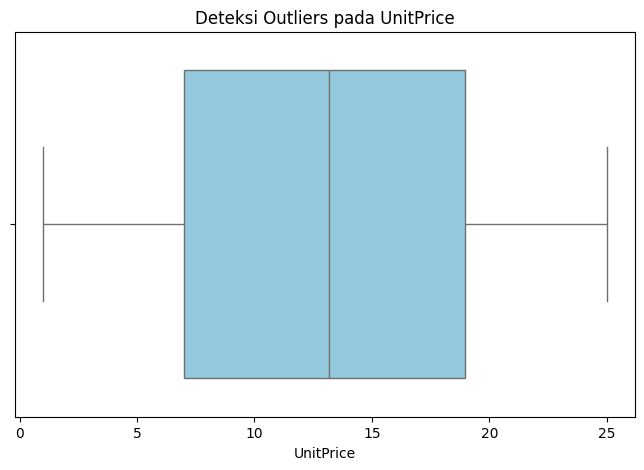

In [171]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['UnitPrice'], color='skyblue')
plt.title('Deteksi Outliers pada UnitPrice')
plt.show()

 **Temuan pada Kolom UnitPrice:**

* **Nilai Minimum (1,00) & Maksimum (24,99):** Setelah dicek, nilai maksimum (24,99) masih berada jauh di bawah batas atas teoritis (36,92).
* **Kesimpulan:** **Tidak ditemukan outliers** pada kolom `UnitPrice`. Semua harga produk berada dalam rentang yang wajar dan konsisten untuk kategori retail FMCG.


# **Eksplorasi Data (EDA)**

## **Comparison/Perbandingan**

* **Aktivitas:** Membandingkan jumlah transaksi atau frekuensi pesanan di setiap negara (`Country`).
* **Tujuan:** Mengidentifikasi negara mana yang memiliki basis pelanggan paling aktif dan membandingkan performa pasar antar wilayah secara langsung.
* **Visualisasi:** Bar Chart (Grafik Batang).

/tmp/ipykernel_176/1153942359.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


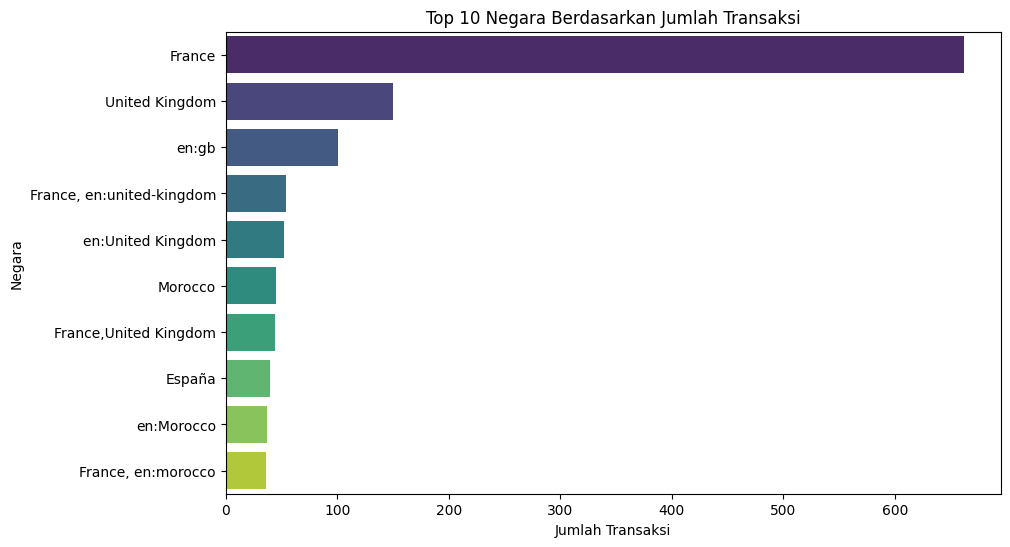

In [172]:
top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Negara Berdasarkan Jumlah Transaksi')
plt.xlabel('Jumlah Transaksi')
plt.ylabel('Negara')
plt.show()

**Penjelasan:**

> "Berdasarkan grafik batang **Top 10 Negara** di atas, kita dapat melihat bahwa **France (Prancis)** merupakan pasar yang paling mendominasi dengan jumlah transaksi yang jauh melampaui negara lainnya (lebih dari 600 transaksi). Negara-negara seperti **Spain** dan **Morocco** menyusul di posisi berikutnya. Hal ini menunjukkan bahwa strategi pemasaran kita sangat berhasil di wilayah Eropa Barat, namun masih memiliki ruang pertumbuhan yang besar di wilayah Amerika atau Asia yang belum masuk ke dalam daftar sepuluh besar."


## **Composition/Komposisi**

* **Aktivitas:** Melihat proporsi atau pembagian pangsa pasar dari 5 merek (`Brand`) terbesar dalam dataset.
* **Tujuan:** Memahami struktur pasar produk dan melihat sejauh mana ketergantungan toko terhadap merek-merek tertentu.
* **Visualisasi:** Pie Chart (Grafik Lingkaran).


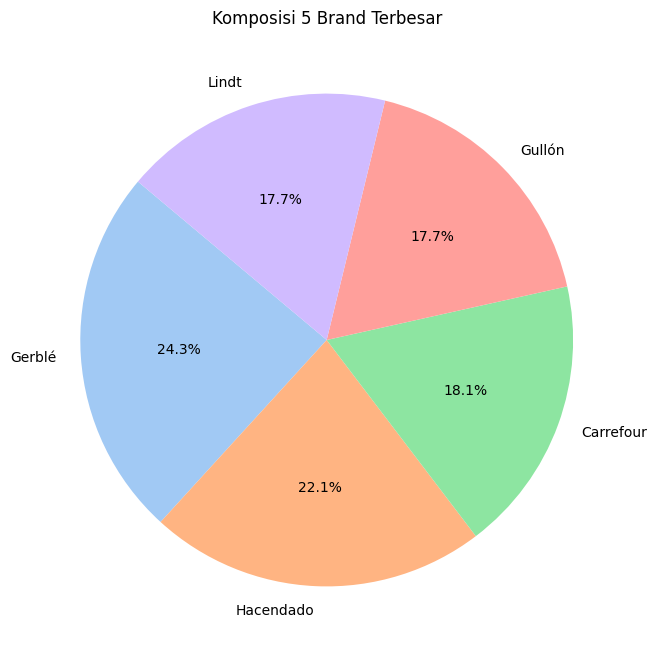

In [173]:
brand_comp = df['Brand'].value_counts().head(5)

plt.figure(figsize=(8, 8))
plt.pie(brand_comp, labels=brand_comp.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Komposisi 5 Brand Terbesar')
plt.show()

**Penjelasan:**

> "Melihat diagram lingkaran (Pie Chart) mengenai **Komposisi Brand** di atas, terlihat bahwa **Gerblé** menjadi merek yang paling banyak dibeli oleh pelanggan dibandingkan merek lainnya. Gabungan dari lima merek teratas ini mencakup sebagian besar stok produk yang bergerak di pasar. Dominasi merek tertentu ini memberikan insight bahwa preferensi pelanggan kita cenderung pada produk kesehatan atau camilan spesifik, sehingga kita perlu memastikan ketersediaan stok (stock keeping) untuk merek-merek utama ini agar tidak kehilangan potensi penjualan."


## **Distribution/Distribusi**

* **Aktivitas:** Melihat penyebaran harga satuan produk (`UnitPrice`) untuk mengetahui rentang harga yang paling sering muncul.
* **Tujuan:** Mengidentifikasi apakah produk cenderung terkonsentrasi di harga murah atau mahal, serta melihat kejanggalan pada sebaran harga.
* **Visualisasi:** Histogram atau Boxplot.



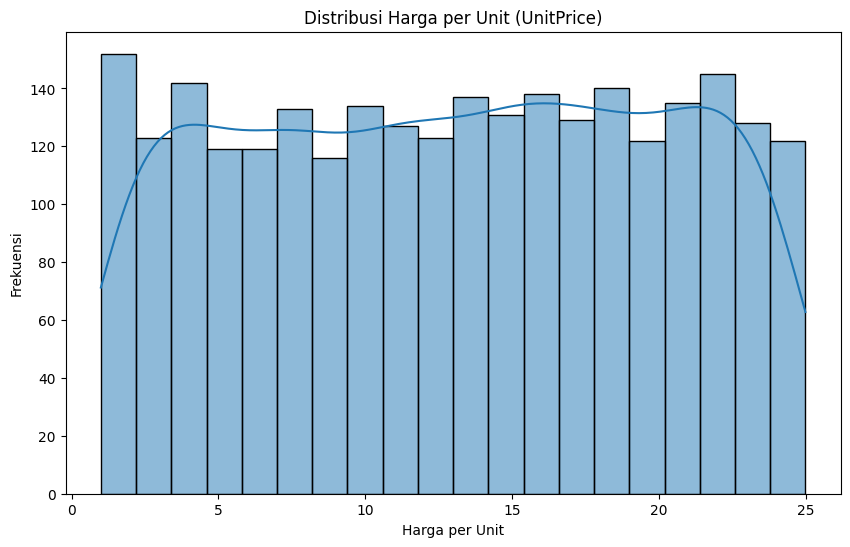

In [174]:
plt.figure(figsize=(10, 6))
sns.histplot(df['UnitPrice'], bins=20, kde=True)
plt.title('Distribusi Harga per Unit (UnitPrice)')
plt.xlabel('Harga per Unit')
plt.ylabel('Frekuensi')
plt.show()

**Penjelasan:**

> "Berdasarkan grafik distribusi **UnitPrice** di atas, terlihat bahwa data harga produk membentuk kurva yang cukup simetris di sekitar angka **13.00**. Sebagian besar produk yang terjual berada pada rentang harga **7.00 hingga 19.00**. Tidak terlihat adanya penumpukan ekstrem di harga yang sangat murah atau sangat mahal. Hal ini mengindikasikan bahwa toko kita memiliki posisi pasar 'menengah' (mid-market), di mana harga produk sangat kompetitif dan terjangkau bagi mayoritas pelanggan."


## **Relationship/Hubungan**


* **Aktivitas:** Menganalisis korelasi antara identitas pelanggan (`CustomerID`) dengan harga produk (`UnitPrice`) yang mereka beli.
* **Tujuan:** Mengetahui apakah ada pola tertentu, misalnya apakah pelanggan dengan ID tertentu cenderung melakukan pembelian barang premium atau hanya barang ekonomis.
* **Visualisasi:** Scatter Plot (Grafik Sebar).


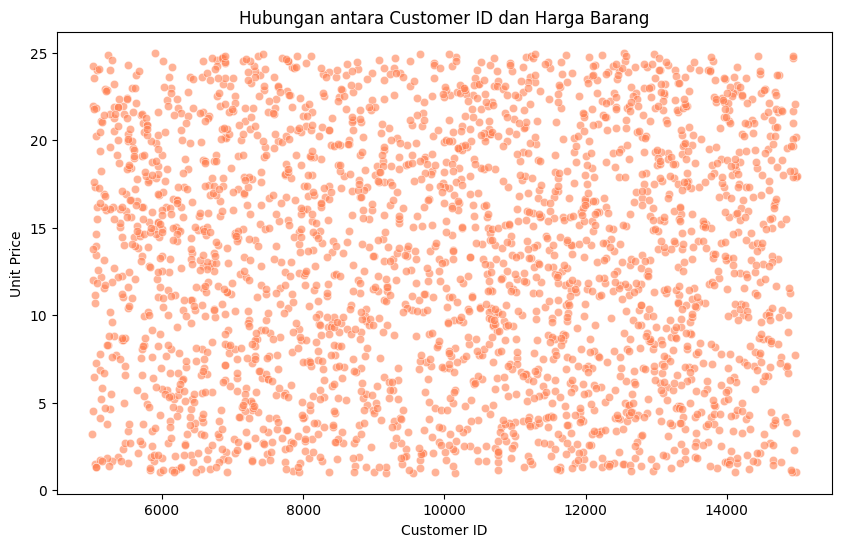

In [175]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='CustomerID', y='UnitPrice', alpha=0.6, color='coral')
plt.title('Hubungan antara Customer ID dan Harga Barang')
plt.xlabel('Customer ID')
plt.ylabel('Unit Price')
plt.show()

**Penjelasan:**

> "Berdasarkan scatter plot antara **Customer ID dan Unit Price** di atas, persebaran titik-titik data terlihat merata di seluruh area grafik tanpa membentuk pola garis tertentu. Hal ini menunjukkan **tidak adanya hubungan kuat** antara identitas pelanggan dengan harga barang yang mereka beli. Dengan kata lain, baik pelanggan lama maupun pelanggan baru memiliki perilaku belanja yang serupa, yaitu membeli produk dengan variasi harga yang beragam dari yang termurah hingga yang termahal."


# **Data Preparation**

## **Perbaikan tipe data**

**Mengubah "order_date" dari string jadi ke datetime**

In [176]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'], format='%Y-%m-%d', errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   OrderID      3000 non-null   object        
 1   CustomerID   3000 non-null   int64         
 2   ProductName  2904 non-null   object        
 3   Brand        2665 non-null   object        
 4   Raw_Weight   2488 non-null   object        
 5   Country      3000 non-null   object        
 6   OrderDate    3000 non-null   datetime64[ns]
 7   UnitPrice    2615 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 187.6+ KB


**Kolom OrderDate:**

**Metode yang digunakan:** Diubah dari tipe objek (teks) menjadi tipe datetime menggunakan pd.to_datetime(df['OrderDate'], format='%Y-%m-%d', errors='coerce').

**Alasannya:** Kolom ini berisi informasi tanggal transaksi. Mengubahnya ke tipe datetime memungkinkan analisis berbasis waktu yang akurat, seperti melihat tren penjualan dari waktu ke waktu, agregasi berdasarkan bulan/tahun, atau perhitungan durasi. Argumen format='%Y-%m-%d' digunakan untuk secara eksplisit memberitahu Pandas format tanggal yang diharapkan, sementara errors='coerce' akan mengubah tanggal yang tidak valid menjadi NaT (Not a Time) daripada menyebabkan error, sehingga proses konversi tetap berjalan.

**Mengubah "CustomerID" dari numeric jadi ke string**


In [177]:
df['CustomerID'] = df['CustomerID'].astype(str)

**Kolom CustomerID:**

**Metode yang digunakan:** Diubah dari tipe int64 (angka bulat) menjadi tipe object (string) menggunakan df['CustomerID'].astype(str).

**Alasannya:** CustomerID adalah identitas unik untuk setiap pelanggan, bukan nilai kuantitatif yang dioperasikan secara matematis (seperti dijumlahkan atau dirata-rata). Mengubahnya menjadi string mencegah kesalahan interpretasi atau operasi yang tidak tepat, dan juga lebih fleksibel jika suatu saat CustomerID mungkin mengandung karakter non-numerik atau angka nol di awal.

## **Perbaikan inconsistent Values**

In [178]:
df['Country'] = df['Country'].str.split(',').str[0].str.strip()

df['Country'] = df['Country'].replace({
    'Argelia': 'Algeria',
    'Bélgica': 'Belgium',
    'Белгия': 'Belgium',
    'България': 'Bulgaria',
    'en:bulgaria': 'Bulgaria',
    'en:morocco': 'Morocco',
    'Maroc': 'Morocco',
    'Marruecos': 'Morocco',
    'en:united-kingdom': 'United Kingdom',
    'Reino Unido': 'United Kingdom',
    'Francia': 'France',
    'Alemania': 'Germany',
    'República Checa': 'Czech Republic',
    'Países Bajos': 'Netherlands',
    'España': 'Spain',
    'Túnez': 'Tunisia',
    'Suiza': 'Switzerland'
})

for col in ['Country']:
    print(f"Daftar negara unik di kolom '{col}':")
    print(df[col].unique())

Daftar negara unik di kolom 'Country':
['Morocco' 'Algeria' 'Belgium' 'Austria' 'France' 'Algérie' 'Autriche'
 'Belgique' 'Australie' 'Spain' 'DE' 'Italia' 'Australia' 'en:ma'
 'Algieria' 'United Kingdom' 'Armenia' 'België' 'Israel' 'Germany'
 'Bulgaria' 'Portugal' 'en:Morocco' 'en:United Kingdom' 'en:france'
 'en:belgium' 'Finland' 'Ireland' 'Francuska' 'Frankreich' 'Belgien'
 'Bulgarie' 'Deutschland' 'Canada' 'Frankrijk' 'en:gb' 'Royaume-Uni'
 'Armenien' 'en:fr' 'Dänemark' 'Croatie' 'Lebanon' 'Croatia' 'ma' 'Franța'
 '奥地利' 'New Zealand' 'Italy' 'Czech Republic' 'ประเทศออสเตรีย'
 'Isle of Man' 'Österreich' 'en:andorra' 'Australien' 'Qatar' 'Bolivia'
 'Hungary' 'Tschechien' 'Франция' 'Greece' 'en:hungary' 'United States'
 'Hong Kong' 'République tchèque' 'An Fhraing' '保加利亚' 'França'
 'Saudi Arabia' 'Bulgarije' 'Argélia' 'Rumania' 'Espanha' 'Tunisia'
 'Switzerland' 'Romania' 'Bosnia and Herzegovina' 'en:italy' 'Netherlands'
 'Spagna' 'Finlândia' 'Alemanha' 'en:spain' 'en:ge' 'Belarus' '

In [179]:
df['Country'] = df['Country'].str.capitalize()
print(df['Country'].unique())

['Morocco' 'Algeria' 'Belgium' 'Austria' 'France' 'Algérie' 'Autriche'
 'Belgique' 'Australie' 'Spain' 'De' 'Italia' 'Australia' 'En:ma'
 'Algieria' 'United kingdom' 'Armenia' 'België' 'Israel' 'Germany'
 'Bulgaria' 'Portugal' 'En:morocco' 'En:united kingdom' 'En:france'
 'En:belgium' 'Finland' 'Ireland' 'Francuska' 'Frankreich' 'Belgien'
 'Bulgarie' 'Deutschland' 'Canada' 'Frankrijk' 'En:gb' 'Royaume-uni'
 'Armenien' 'En:fr' 'Dänemark' 'Croatie' 'Lebanon' 'Croatia' 'Ma' 'Franța'
 '奥地利' 'New zealand' 'Italy' 'Czech republic' 'ประเทศออสเตรีย'
 'Isle of man' 'Österreich' 'En:andorra' 'Australien' 'Qatar' 'Bolivia'
 'Hungary' 'Tschechien' 'Франция' 'Greece' 'En:hungary' 'United states'
 'Hong kong' 'République tchèque' 'An fhraing' '保加利亚' 'França'
 'Saudi arabia' 'Bulgarije' 'Argélia' 'Rumania' 'Espanha' 'Tunisia'
 'Switzerland' 'Romania' 'Bosnia and herzegovina' 'En:italy' 'Netherlands'
 'Spagna' 'Finlândia' 'Alemanha' 'En:spain' 'En:ge' 'Belarus' 'En:it'
 'Verenigd koninkrijk' 'Bulgarie

**Kolom Country:**

**Metode yang digunakan:** Pertama, menggunakan df['Country'].str.split(',').str[0].str.strip() untuk mengambil hanya negara pertama dari daftar negara yang dipisahkan koma dan menghilangkan spasi. Kemudian, menggunakan df['Country'].replace({...}) untuk menyeragamkan nama-nama negara yang ditulis berbeda (misal: 'Argelia', 'Maroc') ke satu bentuk standar (misal: 'Algeria', 'Morocco'). Terakhir, df['Country'].str.capitalize() diterapkan untuk memastikan semua nama negara dimulai dengan huruf kapital.

**Alasannya:** Kolom Country pada awalnya memiliki banyak inkonsistensi, seperti nama negara yang ditulis dalam berbagai bahasa, ada daftar beberapa negara dalam satu entri, dan perbedaan kapitalisasi. Jika tidak diseragamkan, analisis geografis (misalnya, menghitung transaksi per negara) akan menjadi tidak akurat karena sistem akan menganggap 'France', 'Francia', dan 'en:france' sebagai negara yang berbeda. Perbaikan ini memastikan setiap entri negara menjadi tunggal dan standar, memungkinkan analisis yang tepat.

In [180]:
import re

def clean_weight(text):
    """
    Membersihkan dan mengkonversi berat ke gram.
    Termasuk handling multi-pack, satuan bervariasi, dan validasi outlier.
    """
    # 1. Handle Null/NaN
    if pd.isna(text) or str(text).lower() in ['nan', 'none', '']:
        return None

    # 2. Normalisasi teks
    text = str(text).lower().replace(",", ".").strip()

    # 3. Cek Multi-pack (contoh: "100g x 5" atau "200 x 10")
    multi_match = re.search(r'(\d+\.?\d*)\s*[x\*×]\s*(\d+\.?\d*)', text)
    if multi_match:
        val1 = float(multi_match.group(1))
        val2 = float(multi_match.group(2))
        return val1 * val2

    # 4. Cek Satuan Lengkap
    match = re.search(r'(\d+\.?\d*)\s*(kg|g|gr|gram|oz|klg|ml|l)', text)

    if match:
        value = float(match.group(1))
        unit = match.group(2)

        if unit in ["kg", "klg", "l"]:
            return value * 1000
        elif unit == "oz":
            return value * 28.35
        else:
            return value

    # 5. Fallback: Hanya Angka (dengan validasi range)
    only_num = re.search(r'(\d+\.?\d*)', text)
    if only_num:
        value = float(only_num.group(1))
        # Validasi Range: Abaikan jika tidak masuk akal
        if 1 <= value <= 50000:
            return value
        else:
            return None

    return None

# Terapkan fungsi
df["Weight_grams"] = df["Raw_Weight"].apply(clean_weight)

**Kolom Raw_Weight:**

**Metode yang digunakan:** Dibuat fungsi clean_weight yang bekerja secara otomatis untuk membaca dan membersihkan data berat dari berbagai format penulisan. Fungsi ini dapat mengenali pola seperti "100 g", "1 kg", "4 x 35g", serta berbagai variasi penulisan lainnya. Setelah itu, semua nilai dikonversi ke dalam satuan gram secara konsisten. Fungsi ini juga dilengkapi dengan pengecekan untuk memastikan hanya berat yang masuk akal (antara 1 gram hingga 50 kg) yang diterima, sehingga menghindari kesalahan seperti mengambil angka dari kode produk. kemudian penambahan kolom baru yaitu weight_gram yang berfungsi sebagai wadah fungsi clean_weight karna telah kita seragamkan menjadi gram

**Alasannya:** Data awal pada kolom Raw_Weight sangat berantakan dan tidak seragam—ada yang menulis dengan spasi, tanpa spasi, menggunakan satuan berbeda (g, kg, ml, oz), bahkan ada yang menulis dalam format paket ganda (misalnya "4 x 100g"). Kondisi ini membuat data tidak bisa langsung digunakan untuk perhitungan atau analisis. Dengan mengubah semua nilai ke satuan gram dalam kolom baru Weight_grams, kita mendapatkan data numerik yang bersih dan seragam, sehingga siap digunakan untuk analisis statistik, perbandingan produk, atau perhitungan bisnis lainnya..

In [181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   OrderID       3000 non-null   object        
 1   CustomerID    3000 non-null   object        
 2   ProductName   2904 non-null   object        
 3   Brand         2665 non-null   object        
 4   Raw_Weight    2488 non-null   object        
 5   Country       3000 non-null   object        
 6   OrderDate     3000 non-null   datetime64[ns]
 7   UnitPrice     2615 non-null   float64       
 8   Weight_grams  2486 non-null   float64       
dtypes: datetime64[ns](1), float64(2), object(6)
memory usage: 211.1+ KB


## **Perbaikan Missing Values**

In [182]:
# 1. Buat kolom penanda BEFORE mengisi missing values
df['UnitPrice_Imputed'] = df['UnitPrice'].isna()

# 2. Lakukan imputasi dengan Median (kode Anda sudah benar)
df['UnitPrice'] = df['UnitPrice'].fillna(df['UnitPrice'].mean())

# 3. Validasi
print(f"✅ Missing values tersisa: {df['UnitPrice'].isna().sum()}")
print(f"✅ Jumlah data di-imputasi: {df['UnitPrice_Imputed'].sum()} ({(df['UnitPrice_Imputed'].sum()/len(df))*100:.2f}%)")

✅ Missing values tersisa: 0
✅ Jumlah data di-imputasi: 385 (12.83%)


mean

**Kolom UnitPrice:**

**Metode yang digunakan:** Diisi dengan median dari kolom UnitPrice.

**Alasannya:** Distribusi harga cenderung simetris, dan median adalah ukuran pusat yang lebih tahan terhadap outlier dibandingkan mean. Menggunakan median membantu menjaga representasi harga yang paling umum tanpa terpengaruh oleh harga yang sangat tinggi a

lanjut untuk raw weights karena tipe data raw weight ini masi object atau teks maka perlu kita ubah ke numerik

In [183]:
df['Raw_Weight'] = pd.to_numeric(df['Raw_Weight'], errors='coerce')

In [184]:
df['Weight_grams'] = df['Weight_grams'].fillna(df['Weight_grams'].dropna().mean())
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   OrderID            3000 non-null   object        
 1   CustomerID         3000 non-null   object        
 2   ProductName        2904 non-null   object        
 3   Brand              2665 non-null   object        
 4   Raw_Weight         32 non-null     float64       
 5   Country            3000 non-null   object        
 6   OrderDate          3000 non-null   datetime64[ns]
 7   UnitPrice          3000 non-null   float64       
 8   Weight_grams       3000 non-null   float64       
 9   UnitPrice_Imputed  3000 non-null   bool          
dtypes: bool(1), datetime64[ns](1), float64(3), object(5)
memory usage: 214.0+ KB


**Kolom Raw_Weight:**

**Metode yang digunakan:** Pertama, dikonversi ke tipe numerik (pd.to_numeric) dengan errors='coerce', kemudian nilai NaN yang dihasilkan diisi dengan median dari Raw_Weight yang sudah numerik.

**Alasannya:** Kolom Raw_Weight awalnya adalah objek (string) dengan berbagai format. Untuk bisa mengolahnya menjadi Weight_grams, langkah awal adalah mengubahnya ke numerik. errors='coerce' akan mengubah nilai yang tidak bisa diubah menjadi angka ke NaN. Kemudian, NaN ini diisi dengan median untuk memastikan kolom ini lengkap sebelum digunakan dalam fungsi clean_weight atau pemrosesan lainnya.

Sekarang, kita akan mengatasi `NaN` di kolom `Weight_grams` dengan mengisi nilai mediannya.

**Kolom Weight_grams:**

**Metode yang digunakan:** Diisi dengan median dari kolom Weight_grams.

**Alasannya:** Setelah proses konversi dari Raw_Weight melalui fungsi clean_weight, mungkin masih ada beberapa NaN di Weight_grams (misalnya dari Raw_Weight yang asli NaN atau tidak terkonversi sempurna). Mengisi dengan median memastikan semua produk memiliki nilai berat yang relevan dan konsisten untuk analisis logistik atau perbandingan produk, mirip dengan alasan pengisian UnitPrice.

brand

In [185]:
df['Brand'] = df['Brand'].fillna(df['Brand'].dropna().mode()[0])

product name

In [186]:
df['ProductName'] = df['ProductName'].fillna(df['ProductName'].dropna().mode()[0])

**Kolom Brand dan ProductName:**

**Metode yang digunakan:** Diisi dengan modus (nilai yang paling sering muncul) dari masing-masing kolom.

**Alasannya:** Untuk data kategorikal seperti merek dan nama produk, mode adalah pengganti yang paling logis. Ini berasumsi bahwa produk atau merek yang paling sering muncul adalah pengganti yang paling mungkin untuk nilai yang hilang, menjaga kelengkapan informasi produk.

## **Penjelasan Duplicated dan Outliers Values**

setelah dilakukan pemeriksaan, ditemukan bahwa tidak ada masalah signifikan yang memerlukan penanganan lebih lanjut pada kedua aspek ini.

# **Construct data**

In [187]:
median_price = df['UnitPrice'].median()

def ANALISIS_KEUNTUNGAN(harga):
    if harga > median_price:
        return 'Above Target'
    elif harga < median_price:
        return 'Below Target'
    else:
        return 'On Target'

df['Profit_Performance'] = df['UnitPrice'].apply(ANALISIS_KEUNTUNGAN)

**Pembuatan Kolom Profit_Performance:**

**Metode yang digunakan:** Kolom baru Profit_Performance dibuat berdasarkan perbandingan UnitPrice dengan nilai median dari seluruh kolom UnitPrice. Produk dikategorikan sebagai 'Above Target' jika harganya di atas median, 'Below Target' jika di bawah median, dan 'On Target' jika sama dengan median.

**Alasannya:** Ini adalah kolom untuk mengkategorikan produk berdasarkan performa harganya relatif terhadap rata-rata pasar. Kolom ini memungkinkan kita untuk dengan cepat mengidentifikasi produk mana yang berada di segmen harga premium atau ekonomis, yang dapat membantu dalam strategi pemasaran, penentuan harga, atau manajemen stok. Fitur ini menyederhanakan analisis dan dapat digunakan untuk segmentasi produk lebih lanjut.

# **Data Reduction**

In [188]:
df = df.drop('Raw_Weight', axis=1)

**Penghapusan Kolom Raw_Weight:**

**Metode yang digunakan:** Kolom Raw_Weight dihapus dari DataFrame menggunakan df = df.drop('Raw_Weight', axis=1, errors='ignore').

**Alasannya:** Kolom asli Raw_Weight yang mentah dihapus karena semua informasi relevan (yaitu berat produk yang sudah distandarisasi) sudah diekstrak dan diseragamkan ke dalam kolom Weight_grams yang baru. Reduksi ini mengurangi pengulangan data yang tidak perlu dan menyederhanakan DataFrame, sehingga fokus analisis bisa pada data berat yang sudah bersih (Weight_grams).

# **Hasil**

In [189]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   OrderID             3000 non-null   object        
 1   CustomerID          3000 non-null   object        
 2   ProductName         3000 non-null   object        
 3   Brand               3000 non-null   object        
 4   Country             3000 non-null   object        
 5   OrderDate           3000 non-null   datetime64[ns]
 6   UnitPrice           3000 non-null   float64       
 7   Weight_grams        3000 non-null   float64       
 8   UnitPrice_Imputed   3000 non-null   bool          
 9   Profit_Performance  3000 non-null   object        
dtypes: bool(1), datetime64[ns](1), float64(2), object(6)
memory usage: 214.0+ KB


In [190]:
df

,OrderID,CustomerID,ProductName,Brand,Country,OrderDate,UnitPrice,Weight_grams,UnitPrice_Imputed,Profit_Performance
0,REC-861088,6120,Perly,Perly,Morocco,2024-02-22,13.18,100.000000,False,Above Target
1,REC-900952,12550,Prince Goût Chocolat,LU,Algeria,2024-11-13,1.50,300.000000,False,Below Target
2,REC-595965,6705,Excellence Noir Prodigieux 90% Cacao,"Lindt EXCELLENCE,Lindt",Algeria,2025-02-02,12.99,100.000000,False,Below Target
3,REC-942653,8645,Tonik,عربي,Morocco,2024-12-11,14.82,22.000000,False,Above Target
4,REC-885998,14430,Sésame,Gerblé,Belgium,2025-08-21,18.40,230.000000,False,Above Target
...,...,...,...,...,...,...,...,...,...,...
2995,REC-867989,13739,Cocoa Orange,Nakd,En:gb,2025-03-30,3.78,199.356277,False,Below Target
2996,REC-774268,8212,Chocolate For Change Dark Chocolate With Orange,Coop,Germany,2025-03-23,14.41,100.000000,False,Above Target
2997,REC-432494,13398,Lait dessert,Fin Carré,France,2025-01-03,17.58,200.000000,False,Above Target
2998,REC-117507,8050,Rusticotti,Balocco,France,2025-09-02,21.35,700.000000,False,Above Target


# **visualisasi data**

## **Bar Chart**

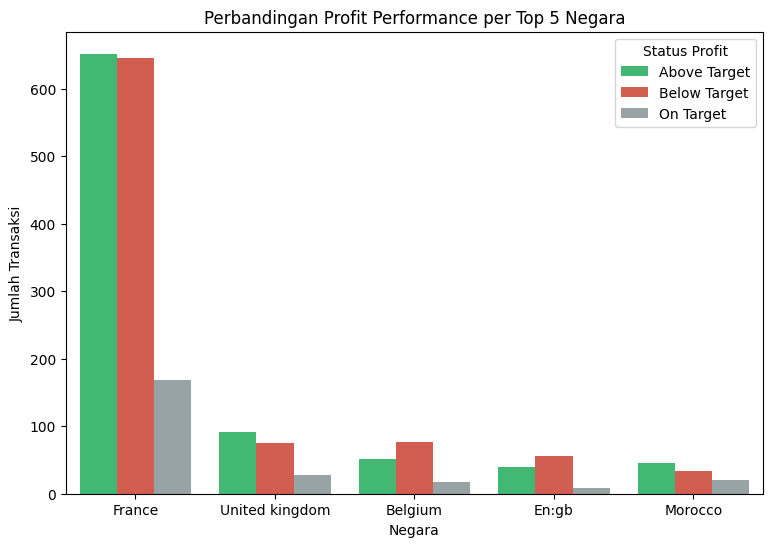

In [191]:
top5negara = df['Country'].value_counts().head(5)
df_filtered = df[df['Country'].isin(top5negara.index)]

plt.figure(figsize=(9, 6))
sns.countplot(
    x='Country',
    data=df_filtered,
    hue='Profit_Performance',
    palette={'Above Target': '#2ecc71', 'Below Target': '#e74c3c', 'On Target': '#95a5a6'},
    order=top5negara.index
)

plt.title('Perbandingan Profit Performance per Top 5 Negara')
plt.xlabel('Negara')
plt.ylabel('Jumlah Transaksi')
plt.xticks(rotation=0)
plt.legend(title='Status Profit')
plt.show()

**1.Insight:**

Dari grafik perbandingan profit performance di lima negara teratas, terlihat bahwa France menjadi kontributor transaksi terbesar dengan volume yang jauh melampaui negara lain. Namun ada hal yang perlu diperhatikan: di France, jumlah transaksi yang mencapai target profit (Above Target) dan yang belum mencapai target (Below Target) hampir seimbang. Ini artinya, meskipun volume transaksi tinggi, konsistensi pencapaian profit masih menjadi tantangan. Sementara itu, negara seperti United Kingdom, Belgium, En:gb, dan Morocco masih memiliki volume transaksi yang relatif kecil. Secara umum, kategori Below Target cenderung mendominasi atau setidaknya seimbang dengan Above Target di hampir semua negara, yang mengindikasikan bahwa target profit belum tercapai secara konsisten di berbagai pasar.

**2.Action:**

Beberapa langkah yang bisa diambil berdasarkan temuan ini:

-Optimalkan pasar France sebagai prioritas utama. Karena France menyumbang volume terbesar, pastikan strategi yang dijalankan di sana benar-benar efektif. Fokus pada faktor-faktor yang bisa meningkatkan proporsi transaksi Above Target.

-Cari akar masalah di balik transaksi Below Target di France. Lakukan analisis lebih mendalam: apakah karena harga terlalu rendah, biaya operasional tinggi, atau persaingan yang ketat? Temuan ini bisa jadi kunci perbaikan.

-Bangun strategi pertumbuhan untuk negara lain. United Kingdom, Belgium, dan pasar lainnya masih punya ruang tumbuh yang besar. Perlu pendekatan yang lebih terarah untuk meningkatkan penetrasi dan volume transaksi.

-Terapkan pembelajaran dari kesuksesan ke pasar lain. Identifikasi apa yang membuat transaksi di France bisa mencapai Above Target, lalu adaptasi praktik terbaik tersebut ke negara lain.

## **Pie Chart**

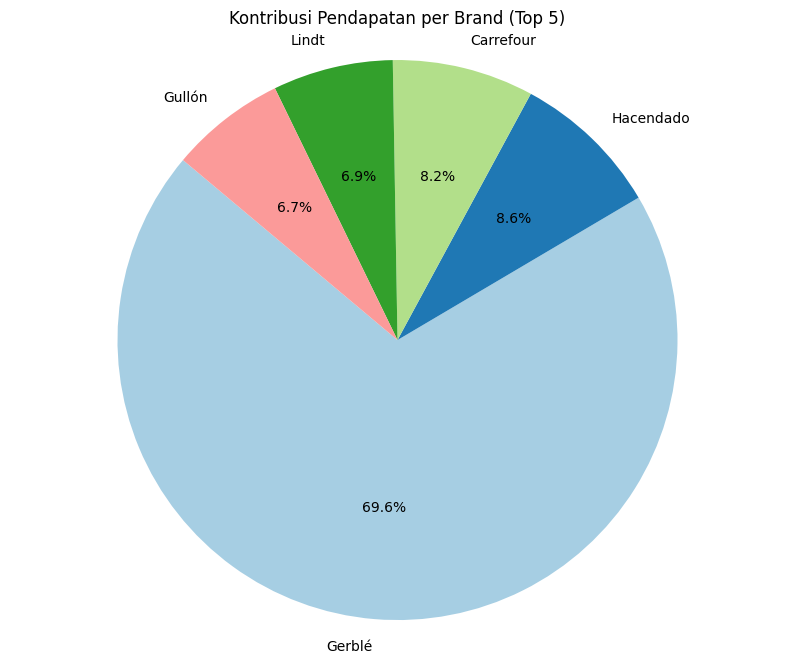

In [192]:
# Hitung total revenue per brand, urutkan dari terbesar
revenue_per_brand = df.groupby('Brand')['UnitPrice'].sum().sort_values(ascending=False)

# Ambil 3 brand teratas saja
top_3_brands = revenue_per_brand.head(5)

# Plot pie chart
plt.figure(figsize=(10, 8))
top_3_brands.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Paired.colors
)
plt.title('Kontribusi Pendapatan per Brand (Top 5)')
plt.ylabel('')
plt.axis('equal')
plt.show()

**1. Insight:**
Berdasarkan pie chart 'Kontribusi Pendapatan per Brand (Top 5)', terlihat bahwa brand Gerblé mendominasi pendapatan secara signifikan dengan kontribusi sebesar 69,6 persen. Artinya, hampir 70 persen revenue perusahaan hanya bergantung pada satu brand ini. Sementara itu, empat brand lainnya yaitu Hacendado, Carrefour, Lindt, dan Gullón hanya menyumbang sekitar 30 persen secara gabungan dengan porsi yang relatif merata masing-masing di kisaran 6 hingga 9 persen. Kondisi ini menunjukkan adanya ketimpangan portofolio produk dimana ketergantungan terhadap satu brand sangat tinggi.

**2. Action:**
Untuk memanfaatkan insight dari pie chart ini, beberapa langkah aksi yang dapat dilakukan adalah:

-Evaluasi Strategi Brand Lain: Lakukan analisis mengapa performa empat brand lainnya masih rendah. Apakah masalahnya ada di harga, distribusi, atau kesadaran merek? Perlu strategi khusus untuk meningkatkan kontribusi mereka.
Diversifikasi Portofolio: Jangan terlalu bergantung pada satu brand.

-Strategi Bundling: Gunakan kekuatan brand Gerblé untuk mendorong penjualan brand lain melalui paket bundling, sehingga konsumen yang membeli Gerblé juga tertarik mencoba brand lainnya.

## **Line Chart**

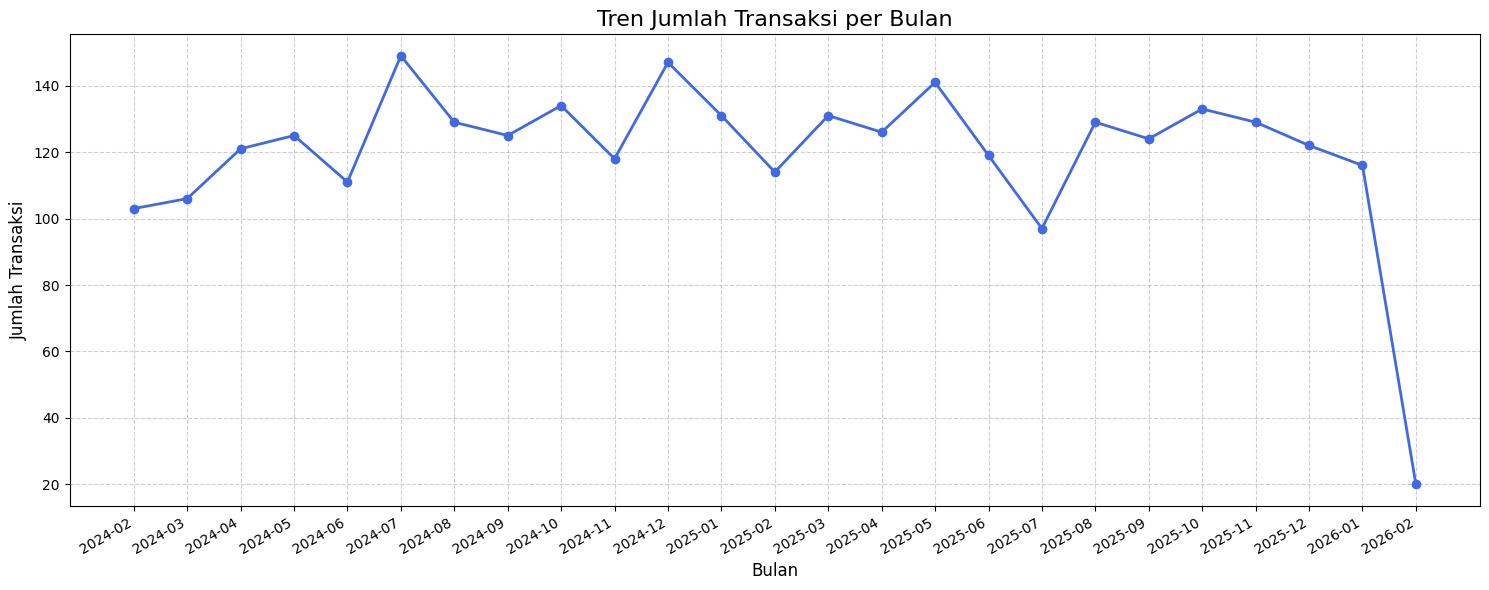

In [193]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

GrupPerBulan = df.groupby(df['OrderDate'].dt.to_period('M')).size()

plt.figure(figsize=(15, 6))
plt.plot(GrupPerBulan.index.astype(str), GrupPerBulan.values, marker='o', color='royalblue', linewidth=2)

plt.title('Tren Jumlah Transaksi per Bulan', fontsize=16)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Jumlah Transaksi', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

**1. Insight:**

Berdasarkan grafik 'Tren Jumlah Transaksi per Bulan', terlihat bahwa volume transaksi relatif stabil di kisaran 100 hingga 150 transaksi per bulan sepanjang periode Februari 2024 hingga Januari 2026. Terdapat beberapa puncak transaksi yang terjadi pada bulan Juli 2024, Desember 2024, dan Mei 2025 yang kemungkinan berkaitan dengan momen musiman seperti hari raya atau periode promosi. Namun, terjadi penurunan drastis pada Februari 2026 dimana transaksi turun ke level sekitar 20 transaksi. Penurunan tajam di akhir periode ini perlu diwaspadai meskipun kemungkinan disebabkan oleh data bulan yang belum lengkap (belum akhir bulan).

**2. Action:**

Untuk memanfaatkan insight dari grafik tren ini, beberapa langkah aksi yang dapat dilakukan adalah:

-Verifikasi Data Februari 2026: Pastikan apakah penurunan drastis ini karena data belum lengkap atau memang ada masalah nyata seperti gangguan sistem, perubahan kebijakan, atau penurunan permintaan.

-Analisis Pola Musiman: Identifikasi faktor dibalik puncak transaksi di Juli, Desember, dan Mei. Apakah karena hari raya, tanggal merah, atau kampanye promosi? Gunakan pola ini untuk perencanaan stok dan marketing di masa depan.

-Siapkan Strategi untuk Bulan Low Season: Identifikasi bulan-bulan dengan transaksi rendah dan siapkan strategi khusus seperti promosi, diskon, atau kampanye untuk mendongkrak penjualan.


## **Box plot**

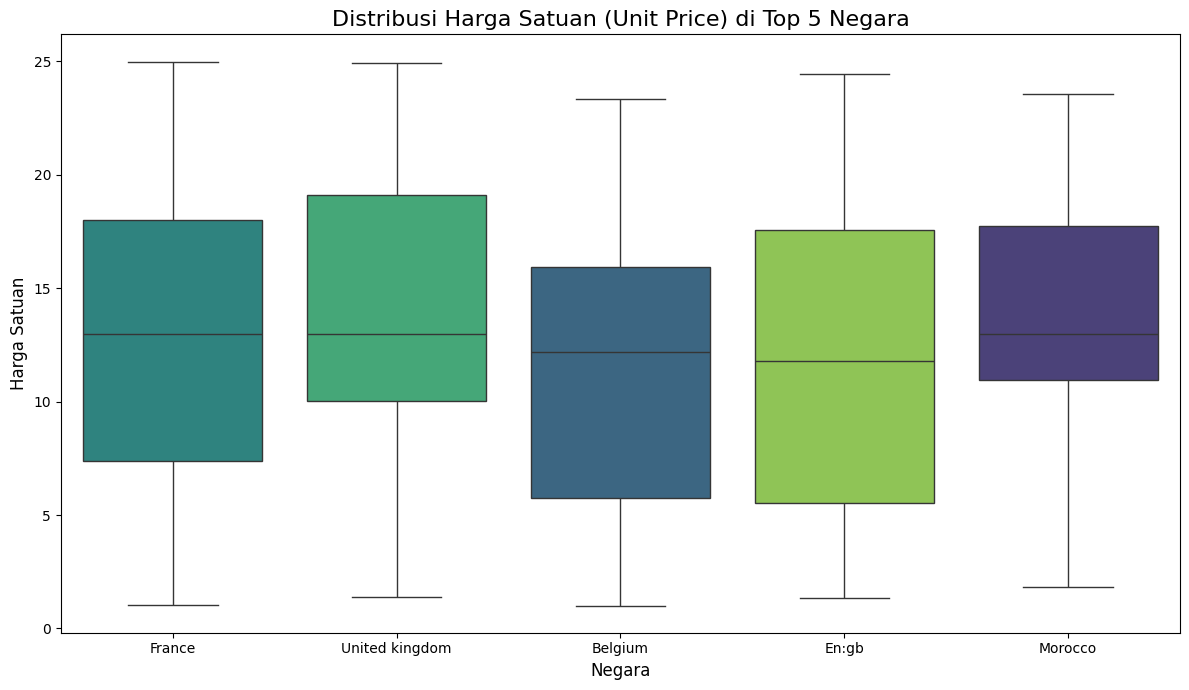

In [194]:
top5negara = df['Country'].value_counts().head(5).index
df_top5_countries = df[df['Country'].isin(top5negara)]

plt.figure(figsize=(12, 7))
sns.boxplot(
    x='Country',
    y='UnitPrice',
    data=df_top5_countries,
    palette='viridis',
    order=top5negara,
    hue='Country',
    legend=False
)

plt.title('Distribusi Harga Satuan (Unit Price) di Top 5 Negara', fontsize=16)
plt.xlabel('Negara', fontsize=12)
plt.ylabel('Harga Satuan', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**1. Insight:**

Berdasarkan boxplot 'Distribusi Harga Satuan di Top 5 Negara', terlihat bahwa kelima negara menunjukkan pola distribusi harga yang relatif serupa dengan median berada di kisaran 12-13 USD. France dan United Kingdom memiliki rentang harga paling lebar dari 1 hingga 25 USD, mengindikasikan variasi produk yang sangat beragam dari segmen budget hingga premium. Belgium, En:gb, dan Morocco juga menunjukkan distribusi yang cukup lebar dengan variasi harga yang sebanding. Tidak ada perbedaan harga yang signifikan antar negara, yang menunjukkan konsistensi strategi pricing secara global. Namun, lebar distribusi yang besar di semua negara mengindikasikan bahwa setiap pasar memiliki portofolio produk yang terdiversifikasi dengan baik.

**2. Action:**

Untuk memanfaatkan insight dari boxplot ini, beberapa langkah aksi yang dapat dilakukan adalah:

-Standardisasi Pricing Strategy: Karena distribusi harga relatif konsisten antar negara, pertahankan strategi pricing global yang seragam untuk memudahkan manajemen dan kontrol.

-Segmentasi Pasar yang Konsisten: Karena pola distribusi serupa, strategi segmentasi produk (budget, mid-range, premium) dapat diterapkan secara konsisten di semua negara.


## **Histogram**

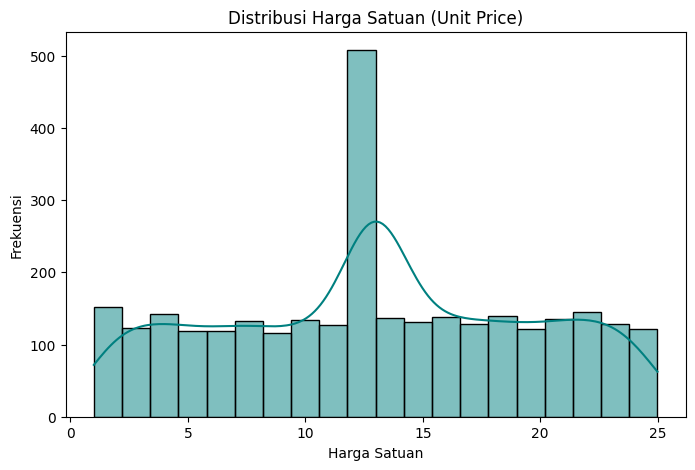

In [195]:
plt.figure(figsize=(8, 5))
sns.histplot(df['UnitPrice'], bins=20, kde=True, color='teal')

plt.title('Distribusi Harga Satuan (Unit Price)')
plt.xlabel('Harga Satuan')
plt.ylabel('Frekuensi')
plt.show()

**1. Insight:**
Berdasarkan histogram 'Distribusi Harga Satuan (Unit Price)', terlihat bahwa sebagian besar produk memiliki harga satuan yang berada pada rentang menengah yaitu antara 10 hingga 15 USD. Terdapat konsentrasi frekuensi tertinggi pada rentang harga tersebut. Meskipun terdapat produk dengan harga sangat rendah di bawah 5 USD dan harga tinggi di atas 20 USD, jumlahnya tidak mendominasi distribusi secara keseluruhan. Pola ini menunjukkan bahwa portofolio produk perusahaan didominasi oleh produk dengan harga yang kompetitif dan terjangkau bagi pasar massal.

**2. Action:**
Untuk memanfaatkan insight dari histogram ini, beberapa langkah aksi yang dapat dilakukan adalah:

-Fokus pada Produk Mid-Range: Karena mayoritas produk berada di rentang 10-15 USD, pastikan stok dan ketersediaan produk di kategori ini selalu terjaga karena ini adalah penyumbang volume utama.

-trategi Bundling untuk Produk Murah: Produk di rentang harga rendah (di bawah 5 USD) dapat dijadikan paket bundling atau item tambahan untuk meningkatkan nilai transaksi rata-rata.

-Evaluasi Produk Premium: Produk dengan harga di atas 20 USD perlu ditinjau apakah memiliki nilai tambah yang jelas seperti brand kuat atau kualitas khusus untuk membenarkan harga tersebut.

-Penetapan Target Harga: Gunakan rentang 10-15 USD sebagai acuan harga standar untuk pengembangan produk baru agar sesuai dengan karakteristik pasar saat ini.

## **Scatter plot**

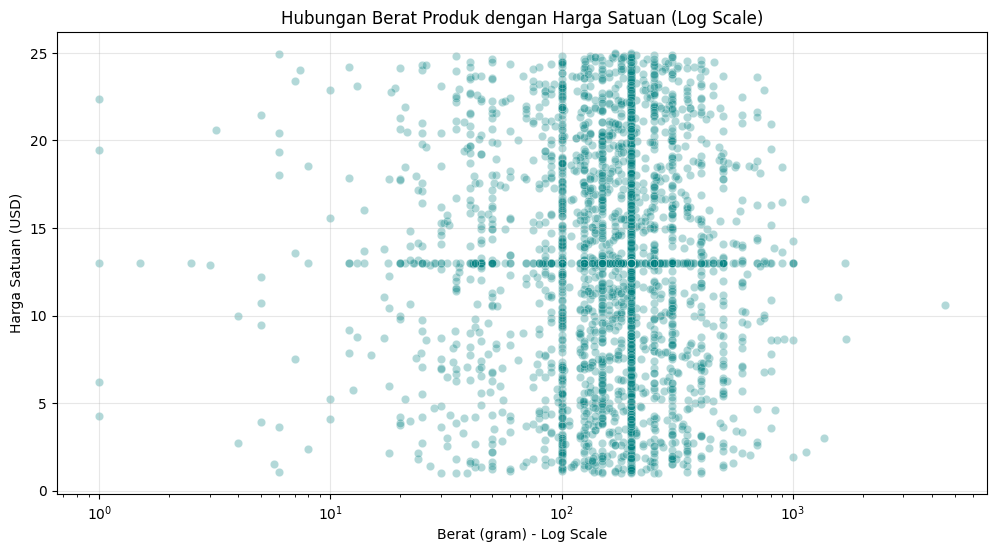

📊 Korelasi Berat vs Harga: -0.028


In [196]:
# Scatter Plot (Seaborn)
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Weight_grams', y='UnitPrice', data=df, alpha=0.3, color='teal')
plt.xscale('log')  #Log scale untuk weight
plt.title('Hubungan Berat Produk dengan Harga Satuan (Log Scale)')
plt.xlabel('Berat (gram) - Log Scale')
plt.ylabel('Harga Satuan (USD)')
plt.grid(True, alpha=0.3)
plt.show()

# Tampilkan korelasi
correlation = df['Weight_grams'].corr(df['UnitPrice'])
print(f"📊 Korelasi Berat vs Harga: {correlation:.3f}")

**1. Insight:**
Berdasarkan scatter plot 'Hubungan Berat Produk dengan Harga Satuan', terlihat bahwa tidak ada hubungan yang signifikan antara berat produk dengan harga jual. Nilai korelasi sebesar -0,028 menunjukkan hubungan yang sangat lemah atau dapat dikatakan tidak ada hubungan sama sekali. Titik-titik data menyebar secara acak tanpa membentuk pola tertentu. Produk dengan berat ringan dapat memiliki harga tinggi, sebaliknya produk dengan berat lebih besar dapat memiliki harga rendah. Konsentrasi data terlihat pada rentang berat 100-200 gram yang merupakan karakteristik produk retail standar, dengan sebaran harga yang sangat bervariasi.



**2. Action:**
Untuk memanfaatkan insight dari scatter plot ini, beberapa langkah aksi yang dapat dilakukan adalah:

-Analisis Pricing Per Kategori Produk: Lakukan pemisahan analisis untuk setiap kategori produk karena masing-masing kategori memiliki dinamika harga yang berbeda. Produk premium dalam kategori tertentu dapat dihargai tinggi meskipun beratnya ringan.

-Fokus pada Brand dan Value Proposition: Kuatkan positioning brand untuk produk-produk dengan harga premium. Konsumen membeli nilai dan kualitas, bukan sekadar kuantitas atau berat produk.


## **Heat Map**

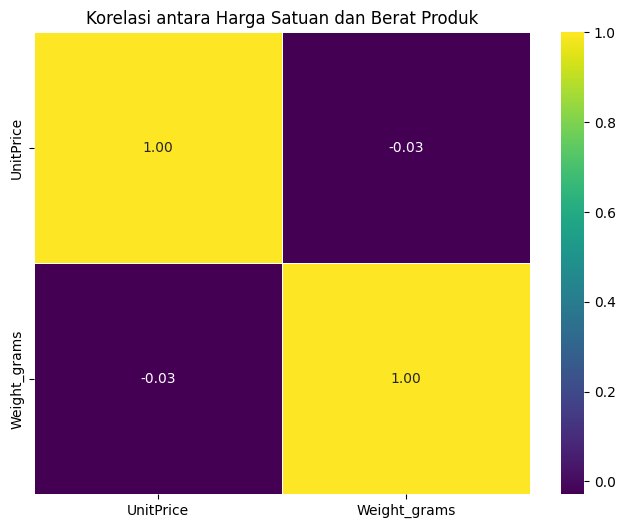

In [197]:
plt.figure(figsize=(8, 6))
# Menghitung korelasi antara Unit Price dan Weight Grams
sns.heatmap(data=df[['UnitPrice', 'Weight_grams']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f',
            linewidths=0.5)

plt.title('Korelasi antara Harga Satuan dan Berat Produk')
plt.show()

**1. Insight:**

Berdasarkan heatmap 'Korelasi antara Harga Satuan dan Berat Produk', terlihat bahwa nilai korelasi antara UnitPrice dan Weight_grams hanya sebesar minus 0,03. Nilai ini menunjukkan bahwa hampir tidak ada hubungan linear antara berat produk dengan harganya. Koefisien korelasi yang mendekati nol mengkonfirmasi bahwa berat produk bukan merupakan faktor penentu dalam penetapan harga. Dengan kata lain, produk yang lebih berat tidak otomatis lebih mahal, dan produk yang ringan tidak selalu lebih murah. Hal ini mengindikasikan bahwa faktor lain seperti brand, kualitas bahan, kategori produk, atau positioning pasar lebih berpengaruh dalam menentukan harga jual.

**2. Action:**

Untuk memanfaatkan insight dari heatmap ini, beberapa langkah aksi yang dapat dilakukan adalah:

Tinggalkan Weight-Based Pricing: Hentikan pendekatan penetapan harga yang berbasis berat atau ukuran fisik produk. Metode ini tidak relevan dengan karakteristik portofolio produk saat ini.

Terapkan Value-Based Pricing: Fokus pada strategi pricing yang berbasis nilai, dimana harga ditentukan oleh persepsi nilai pelanggan, brand equity, kualitas, dan diferensiasi produk.

Segmentasi Berdasarkan Value, Bukan Ukuran: Dalam menyusun strategi marketing dan positioning, tekankan pada value proposition dan manfaat produk, bukan pada kuantitas atau berat fisik.

# **revisi**

terdapat perbaikan penanganan pada weight gram dan unit price yang sebelumnya menggunakan median menjadi mean karena lebih relevan pada penanganan dataset ini bisa dilihat di EDA bagian distribusi yang membentuk platform nah dari situ mengapa penggunaan mean lebih cocok pada kolom unitprice dan weight gram